# TURBO LP 大户撤资：90 天可行性研究

本 Notebook 只生成可复核的数据、表格和图像，不构建决策树，也不输出自动投资决策。

范围：Ethereum 上 TURBO/WETH 的 Uniswap V3 主池。通过 Pool `Mint/Burn` 与 Position Manager `IncreaseLiquidity/DecreaseLiquidity` 的同交易金额匹配恢复 `tokenId`，再读取事件前历史状态，计算单 NFT 的有效流动性份额。

限制（白话）：当前每条撤资记录只计算“这次被撤掉的那个 LP NFT”在撤资前占池子有效流动性的比例，不代表这个钱包全部 LP 仓位的总和。钱包可能同时还有其他没有操作的 LP NFT，因此本研究暂不报告钱包的总份额。另外，不同时间发生的“撤掉旧 NFT、再创建新 NFT”通常是换仓或重建仓位，旧、新 NFT 的份额不能相加。

In [1]:
from __future__ import annotations
import json, sys, time
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from IPython.display import Markdown, display
from web3.logs import DISCARD

ROOT = Path.cwd()
if not (ROOT / "src").exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
load_dotenv(ROOT / ".env")
from src.client import get_contract, get_web3
from scripts.trace_v3_positions import match_position_manager_event

TOKEN = "0xA35923162C49cF95e6BF26623385eb431ad920D3"  # TURBO 合约
POOL = "0x7baecE5d47f1BC5E1953FBE0E9931D54DAB6D810"  # TURBO/WETH V3 主池
POSITION_MANAGER = "0xC36442b4a4522E871399CD717aBDD847Ab11FE88"  # 管理 V3 LP NFT 的官方合约
WINDOW_DAYS = 90  # 研究最近 90 天
OUTPUT_DIR = ROOT / "output-turbo-lp-whale-90d"
CACHE_DIR = OUTPUT_DIR / "notebook_cache"
DATA_DIR = ROOT / "notebooks/data/turbo_lp_whale"
FIGURE_DIR = ROOT / "notebooks/figures/turbo_lp_whale"
for folder in (OUTPUT_DIR, CACHE_DIR, DATA_DIR, FIGURE_DIR): folder.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
w3 = get_web3()
pool_contract = get_contract(w3, POOL, "uniswap_v3_pool")
manager_contract = get_contract(w3, POSITION_MANAGER, "uniswap_v3_position_manager")
print("RPC connected:", w3.is_connected())

RPC connected: True


## 1. 研究窗口与主池事件

### 这部分具体做了什么、结果在哪里？

**第一件事：确定这次到底研究哪一段数据。**

代码先检查以前有没有保存过研究窗口：有就继续使用，避免每次打开都换一批数据；没有才从最新 `finalized` 区块向前寻找 90 天。代码下面的**第一张表**就是这一步的结果。本次实际研究 TURBO/WETH 主池从区块 `25241305` 到 `25886879`，对应 UTC `2026-06-04 03:20:59` 至 `2026-09-02 03:20:59`，共 90 天。

**第二件事：把这 90 天池子里发生过的三类基础动作找出来。**

代码分段读取 TURBO/WETH 主池的事件记录，并在本地保存进度。代码下面的**第二张表**就是统计结果：`Swap` 3,879 条、`Mint` 455 条、`Burn` 460 条。这里 `Swap` 是池内交易，`Mint` 是增加流动性，`Burn` 是减少某个 LP 仓位的流动性；它们不是发行或销毁 TURBO 代币。

所以这一节的重点不是得出“大户撤资”的结论，而是先把研究样本范围和可供后续分析的原始事件准备清楚。仅凭 455 次 `Mint` 和 460 次 `Burn`，还不能判断资金是净流入还是净流出，因为每次金额不同，而且撤掉旧仓位后可能很快重新建仓。

### 为什么使用 `finalized` 区块？

新建研究窗口时，代码直接把 Ethereum 节点返回的最新 `finalized` 区块作为终点。白话就是：只使用网络已经正式确认、基本不会再改的数据，不再由我们自己猜需要等待多少个区块。

本次 TURBO 结果继续复用已经冻结的原窗口，所以旧输出表仍显示 64；这样不会悄悄改变已经完成的样本。以后新建窗口将使用 `finalized`。

In [2]:
# 如果以前已经确定过研究范围，就直接复用，避免每次打开 Notebook 都得到不同的 90 天。
window_path = DATA_DIR / "window.json"
if window_path.exists():
    window = json.loads(window_path.read_text(encoding="utf-8"))
    from_block, to_block = int(window["from_block"]), int(window["to_block"])
    print("Using frozen research window:", from_block, to_block)
else:
    # 只有第一次运行时才计算范围：以网络已经正式确认的 finalized 区块为终点。
    to_header = w3.eth.get_block("finalized")
    to_block = int(to_header.number)
    target_ts = int(to_header.timestamp) - WINDOW_DAYS * 86400
    # 区块编号本身不是日期。这里用二分查找，找到约 90 天前对应的起始区块。
    low, high = 1, to_block
    while low < high:
        middle = (low + high) // 2
        if int(w3.eth.get_block(middle).timestamp) < target_ts: low = middle + 1
        else: high = middle
    from_block = low
    from_header = w3.eth.get_block(from_block)
    window = {
        "token": TOKEN, "pool": POOL, "position_manager": POSITION_MANAGER,
        "from_block": from_block, "to_block": to_block,
        "from_utc": datetime.fromtimestamp(int(from_header.timestamp), timezone.utc).isoformat(),
        "to_utc": datetime.fromtimestamp(int(to_header.timestamp), timezone.utc).isoformat(),
        "window_days": WINDOW_DAYS, "end_block_policy": "ethereum_finalized",
    }
    window_path.write_text(json.dumps(window, indent=2), encoding="utf-8")
# 把研究对象、区块范围和现实时间显示成第一张表，方便人工核验。
display(pd.DataFrame([window]).T.rename(columns={0: "value"}))

def scalar(value):
    if isinstance(value, (bytes, bytearray)): return "0x" + bytes(value).hex()
    if hasattr(value, "hex") and not isinstance(value, str):
        try: return value.hex()
        except Exception: pass
    return value

# 分段抓取一种池子事件。一次读太多区块容易让 RPC 超时，所以默认每批 10,000 个区块。
def scan_event(name, start_block, end_block, initial_chunk=10_000):
    stem = f"{name}_{start_block}_{end_block}"
    raw_path, checkpoint_path = CACHE_DIR / f"{stem}.jsonl", CACHE_DIR / f"{stem}.checkpoint.json"
    rows = [json.loads(line) for line in raw_path.read_text(encoding="utf-8").splitlines() if line] if raw_path.exists() else []
    completed = json.loads(checkpoint_path.read_text())["completed"] if checkpoint_path.exists() else start_block - 1
    cursor, chunk, ceiling = max(start_block, int(completed) + 1), initial_chunk, initial_chunk
    event = getattr(pool_contract.events, name)
    started = time.time()
    # 每成功一段就保存结果和进度；中途停止后可以接着跑，不必从头抓取。
    while cursor <= end_block:
        chunk_end = min(cursor + chunk - 1, end_block)
        try:
            entries = event.get_logs(from_block=cursor, to_block=chunk_end)
        except Exception:
            # 如果节点嫌单次范围太大，就缩小每批区块数量后重试。
            if chunk <= 10: raise
            ceiling, chunk = max(10, chunk // 2), min(100, max(10, chunk // 2))
            continue
        fresh = []
        for entry in entries:
            row = {"event_type": name, "block_number": int(entry["blockNumber"]),
                   "transaction_hash": entry["transactionHash"].hex(), "log_index": int(entry["logIndex"])}
            row.update({key: scalar(value) for key, value in dict(entry["args"]).items()})
            fresh.append(row)
        if fresh:
            with raw_path.open("a", encoding="utf-8") as handle:
                for row in fresh: handle.write(json.dumps(row) + "\n")
            rows.extend(fresh)
        checkpoint_path.write_text(json.dumps({"completed": chunk_end}), encoding="utf-8")
        cursor = chunk_end + 1
        if chunk < ceiling: chunk = min(ceiling, chunk * 2)
        if fresh or chunk_end == end_block:
            progress = (chunk_end - start_block + 1) / (end_block - start_block + 1)
            print(f"{name}: {progress:.1%}, rows={len(rows):,}, elapsed={time.time()-started:.1f}s")
    return pd.DataFrame(rows).sort_values(["block_number", "log_index"]).reset_index(drop=True)

# 分别抓取交易、增加流动性、减少流动性三类事件。
swaps = scan_event("Swap", from_block, to_block)
mints = scan_event("Mint", from_block, to_block)
burns = scan_event("Burn", from_block, to_block)
# 这里只统计事件条数；还不能仅凭数量判断资金净流入或净流出。
event_counts = pd.DataFrame({"event": ["Swap", "Mint", "Burn"], "count": [len(swaps), len(mints), len(burns)]})
event_counts.to_csv(DATA_DIR / "event_counts.csv", index=False)
display(event_counts)

Using frozen research window: 25241305 25886879


,value
token,0xA35923162C49cF95e6BF26623385eb431ad920D3
pool,0x7baecE5d47f1BC5E1953FBE0E9931D54DAB6D810
position_manager,0xC36442b4a4522E871399CD717aBDD847Ab11FE88
from_block,25241305
to_block,25886879
from_utc,2026-06-04T03:20:59+00:00
to_utc,2026-09-02T03:20:59+00:00
window_days,90
stable_confirmations,64


,event,count
0,Swap,3879
1,Mint,455
2,Burn,460


## 2. 时间、价格与每日活动

### 为什么要做这一部分？

上一节只得到 90 天内所有 `Swap`、`Mint` 和 `Burn` 的原始记录，但区块编号不能直接让人看出“哪天活跃、哪天冷清”。这一节把原始记录整理成按天排列的市场时间表，为后面比较“大户撤资前后，价格和交易活动有没有变化”做准备。

### 代码具体做了什么？

1. 查询每个事件所在区块的现实时间，并统一换成 UTC 日期；
2. 把 Swap 中带正负号的代币变化取绝对值，因为这里统计成交规模，不区分买入还是卖出；
3. 按天汇总 Swap 次数、TURBO 成交量和 WETH 成交量；
4. 同时计算两个每日价格：当天最后一笔 Swap 的价格，以及按 TURBO 成交量加权的每日 VWAP；
5. 按天统计增加流动性和减少流动性事件各有多少次；
6. 把以上结果合并成一张每日活动表，并保存为 `notebooks/data/turbo_lp_whale/daily_pool_activity.csv`。

### 下面的表怎么看？

代码使用 `tail(10)`，所以这里只展示整张每日表的最后 10 行，不是只研究这 10 天。`swap_count` 是当天 Swap 事件数；`target_volume` 是 TURBO 成交量；`weth_volume` 是 WETH 成交量；`price_vwap_weth` 是当天按 TURBO 成交量加权的平均成交价格；`price_close_weth` 是当天最后一笔 Swap 的价格；`add_count` 和 `remove_count` 分别是当天增加、减少流动性的事件次数。

注意：`add_count` 和 `remove_count` 只是次数，不是资金金额，不能用二者相减判断资金净流入。最后一行 `2026-09-02` 也不是完整一天，本次窗口只统计到 UTC 03:20:59，因此当天只有 7 次 Swap 不能解释成交易突然萎缩。表格下方的图直接比较每日 VWAP（蓝线）和每日最后价格（黑线）：两条线接近说明最后一笔价格与当天主要成交价格接近，差距较大则说明当天收尾价格与全天主要成交水平不同。

,date_utc,swap_count,target_volume,weth_volume,price_close_weth,price_vwap_weth,add_count,remove_count
81,2026-08-24 00:00:00+00:00,65,7.566653e+06,3.181916,0.0,0.0,0.0,0.0
82,2026-08-25 00:00:00+00:00,43,2.108887e+06,0.885674,0.0,0.0,0.0,0.0
83,2026-08-26 00:00:00+00:00,46,4.386203e+06,1.788890,0.0,0.0,0.0,0.0
84,2026-08-27 00:00:00+00:00,31,1.910303e+06,0.761005,0.0,0.0,0.0,0.0
85,2026-08-28 00:00:00+00:00,84,9.316187e+06,4.173703,0.0,0.0,1.0,1.0
86,2026-08-29 00:00:00+00:00,102,6.630885e+06,2.823773,0.0,0.0,4.0,3.0
87,2026-08-30 00:00:00+00:00,25,1.162635e+06,0.463951,0.0,0.0,0.0,0.0
88,2026-08-31 00:00:00+00:00,23,3.176696e+06,1.187533,0.0,0.0,0.0,0.0
89,2026-09-01 00:00:00+00:00,39,1.738586e+06,0.673601,0.0,0.0,2.0,2.0
90,2026-09-02 00:00:00+00:00,7,1.191926e+05,0.046776,0.0,0.0,5.0,5.0


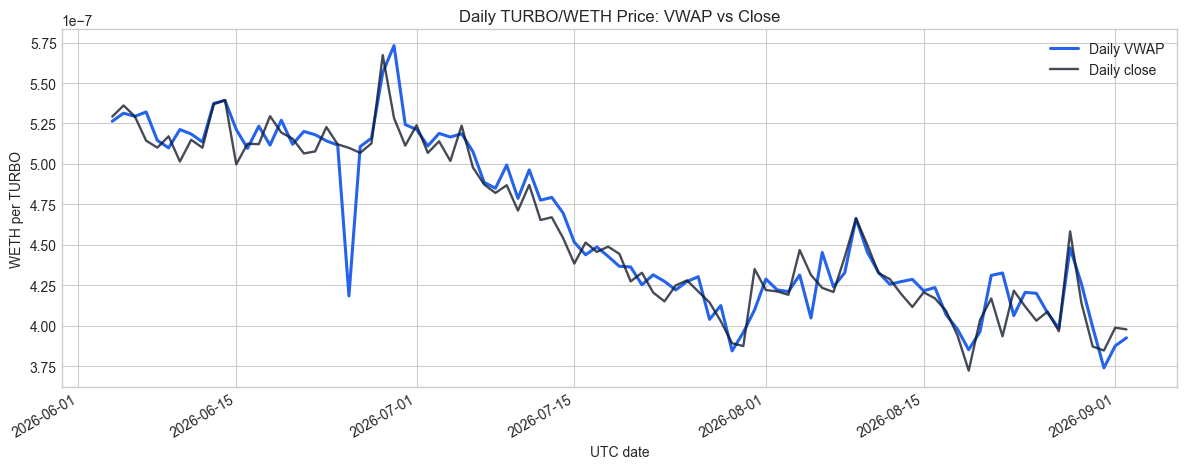

In [3]:
timestamp_path = CACHE_DIR / f"block_timestamps_{from_block}_{to_block}.csv"
timestamp_map = {}
if timestamp_path.exists():
    cached = pd.read_csv(timestamp_path)
    timestamp_map = dict(zip(cached.block_number.astype(int), cached.timestamp.astype(int)))
blocks = sorted(set(swaps.block_number) | set(mints.block_number) | set(burns.block_number))
missing = [block for block in blocks if block not in timestamp_map]
def fetch_timestamp(block): return int(block), int(w3.eth.get_block(int(block)).timestamp)
if missing:
    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = [executor.submit(fetch_timestamp, block) for block in missing]
        for index, future in enumerate(as_completed(futures), 1):
            block, timestamp = future.result(); timestamp_map[block] = timestamp
            if index % 250 == 0: print(f"timestamps: {index:,}/{len(missing):,}")
    pd.DataFrame(sorted(timestamp_map.items()), columns=["block_number", "timestamp"]).to_csv(timestamp_path, index=False)
for frame in (swaps, mints, burns):
    frame["timestamp"] = frame.block_number.map(timestamp_map).astype(int)
    frame["datetime_utc"] = pd.to_datetime(frame.timestamp, unit="s", utc=True)
    frame["date_utc"] = frame.datetime_utc.dt.floor("D")
swaps["target_amount"] = swaps.amount0.abs() / 1e18
swaps["weth_amount"] = swaps.amount1.abs() / 1e18
swaps["price_weth_per_turbo"] = swaps.weth_amount / swaps.target_amount.replace(0, np.nan)
daily_swaps = swaps.groupby("date_utc").agg(swap_count=("transaction_hash", "size"), target_volume=("target_amount", "sum"), weth_volume=("weth_amount", "sum"), price_close_weth=("price_weth_per_turbo", "last")).reset_index()
# VWAP = 当天累计 WETH 成交量 / 当天累计 TURBO 成交量。它表示当天资金主要在哪个价格成交。
daily_swaps["price_vwap_weth"] = daily_swaps.weth_volume / daily_swaps.target_volume.replace(0, np.nan)
daily_liquidity = pd.concat([mints.assign(add_count=1, remove_count=0), burns.assign(add_count=0, remove_count=1)]).groupby("date_utc").agg(add_count=("add_count", "sum"), remove_count=("remove_count", "sum")).reset_index()
daily = daily_swaps.merge(daily_liquidity, on="date_utc", how="outer").sort_values("date_utc")
# 没发生某类事件时，次数和成交量可以记为 0；没有 Swap 时价格应保留为空，不能伪装成价格为 0。
zero_when_missing = ["swap_count", "target_volume", "weth_volume", "add_count", "remove_count"]
daily[zero_when_missing] = daily[zero_when_missing].apply(pd.to_numeric, errors="coerce").fillna(0)
daily.to_csv(DATA_DIR / "daily_pool_activity.csv", index=False)
display(daily.tail(10))

# Part 2 直接展示两个每日价格指标；这里还不叠加后面才识别出的候选撤资日期。
fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(daily.date_utc, daily.price_vwap_weth, color="#2563eb", linewidth=2.2, label="Daily VWAP")
ax.plot(daily.date_utc, daily.price_close_weth, color="#111827", linewidth=1.7, alpha=.78, label="Daily close")
ax.set_title("Daily TURBO/WETH Price: VWAP vs Close")
ax.set_xlabel("UTC date"); ax.set_ylabel("WETH per TURBO"); ax.legend()
fig.autofmt_xdate(); fig.tight_layout()
part2_price_figure = FIGURE_DIR / "turbo_daily_vwap_vs_close.png"
fig.savefig(part2_price_figure, dpi=180, bbox_inches="tight")
plt.show()

## 3. 同交易恢复 NFT tokenId

### 为什么要做这一部分？

Pool 的 `Mint/Burn` 只告诉我们“池子里有一笔流动性增加或减少”，却不直接告诉我们是具体哪张 LP NFT 在操作。没有 NFT 编号（`tokenId`），后面就无法查询这张仓位当时属于谁，也无法把它前后的操作连起来。

可以把它理解成对账：池子账本写着“这笔交易增加了这些 TURBO 和 WETH”，Position Manager 账本写着“同一笔交易里的 NFT #123 增加了完全相同的数量”。两边金额对上后，我们才把池子动作认定为 NFT #123 的动作。

### 代码具体怎么做？

1. 找出所有出现 Pool `Mint/Burn` 的交易哈希；
2. 读取每笔交易的完整回执，同时查看 Pool 和 Position Manager 发出的事件；
3. Pool `Mint` 只与同一交易里的 `IncreaseLiquidity` 匹配，Pool `Burn` 只与 `DecreaseLiquidity` 匹配；
4. 要求两边的 `amount0` 和 `amount1` 完全相同，才取出 Position Manager 记录的 `tokenId`，不靠时间接近进行猜测；
5. 保存匹配进度，最后统计成功率。

### 结果怎么理解？

460 条 Burn 中有 451 条找到了对应 NFT，原始覆盖率 98.04%；455 条 Mint 中有 453 条匹配成功，原始覆盖率 99.56%。没有匹配上的 11 条并不是随机漏抓：其中 7 条是流动性变化为 0 的 Burn，只是在领取手续费前刷新账目，并没有撤出流动性；另外 4 条（2 Mint、2 Burn）由自定义合约直接管理，没有经过官方 Position Manager，因此不存在可按本方法恢复的标准 NFT `tokenId`。

换句话说，在确实经过官方 Position Manager、并且真正增加或减少流动性的记录中，本次金额严格匹配没有漏掉事件。表里的 98.04% 和 99.56% 是“全部 Pool 事件中有多少能连接到标准 NFT”，不是代码识别正确率只有这么高。无法连接到标准 NFT 的记录不会被强行猜测。

这一部分还没有判断 NFT 属于哪个大户，也没有判断资金是否真的离场；它只是先回答“这次加仓或撤仓对应哪张 LP NFT”。所有者、份额和后续行为要在下一部分继续查询。

In [4]:
matched_path = CACHE_DIR / f"matched_position_events_{from_block}_{to_block}.csv"
def decode_events(contract, names, receipt):
    output = []
    for name in names:
        for event in getattr(contract.events, name)().process_receipt(receipt, errors=DISCARD):
            output.append({"event_type": name, "log_index": int(event.get("logIndex") or 0), **{key: scalar(value) for key, value in event["args"].items()}})
    return sorted(output, key=lambda row: row["log_index"])
def match_tx(tx_hash):
    receipt = w3.eth.get_transaction_receipt(tx_hash)
    pool_events = decode_events(pool_contract, ("Mint", "Burn"), receipt)
    manager_events = decode_events(manager_contract, ("IncreaseLiquidity", "DecreaseLiquidity", "Transfer"), receipt)
    used, output = set(), []
    for event in pool_events:
        matched = match_position_manager_event(event, manager_events, used)
        output.append({"block_number": int(receipt["blockNumber"]), "transaction_hash": tx_hash,
            "tx_from": str(receipt["from"]), "pool_event": event["event_type"], "pool_log_index": event["log_index"],
            "tick_lower": int(event["tickLower"]), "tick_upper": int(event["tickUpper"]),
            "liquidity_delta": int(event["amount"]), "amount0": int(event["amount0"]), "amount1": int(event["amount1"]),
            "manager_event": matched["event_type"] if matched else "", "token_id": int(matched["tokenId"]) if matched else np.nan})
    return output
all_hashes = sorted(set(mints.transaction_hash) | set(burns.transaction_hash))
if matched_path.exists():
    existing = pd.read_csv(matched_path)
    rows = existing.to_dict("records")
    completed_hashes = set(existing.transaction_hash)
else:
    rows, completed_hashes = [], set()
hashes = [tx_hash for tx_hash in all_hashes if tx_hash not in completed_hashes]
if hashes:
    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = [executor.submit(match_tx, tx_hash) for tx_hash in hashes]
        for index, future in enumerate(as_completed(futures), 1):
            rows.extend(future.result())
            if index % 50 == 0 or index == len(hashes):
                partial = pd.DataFrame(rows).sort_values(["block_number", "pool_log_index"])
                partial["timestamp"] = partial.block_number.map(timestamp_map).astype(int)
                partial["datetime_utc"] = pd.to_datetime(partial.timestamp, unit="s", utc=True)
                partial.to_csv(matched_path, index=False)
                print(f"receipts: {index:,}/{len(hashes):,}; cached rows={len(partial):,}")
position_events = pd.read_csv(matched_path)
position_events["token_id"] = pd.to_numeric(position_events.token_id, errors="coerce").astype("Int64")
match_summary = position_events.groupby("pool_event").agg(pool_events=("transaction_hash", "size"), matched_token_ids=("token_id", "count")).reset_index()
match_summary["match_rate"] = match_summary.matched_token_ids / match_summary.pool_events
match_summary.to_csv(DATA_DIR / "position_match_summary.csv", index=False)
display(match_summary)

,pool_event,pool_events,matched_token_ids,match_rate
0,Burn,460,451,0.980435
1,Mint,455,453,0.995604


## 4. 撤资前历史份额与候选事件

### 为什么要做这一部分？

Part 3 已经找到了每次减少流动性对应的 LP NFT，但还不知道它是小仓位还是足以影响池子的大仓位。Part 4 回到每次 Burn 所在区块的前一个区块，读取当时的 NFT 所有者、仓位流动性、价格所在 tick 和全池当前有效流动性，再计算这次操作有多大。使用历史状态很重要，因为 Burn 之后再查询，NFT 里的流动性可能已经变成 0。

### 三个核心比例（最重要）

| 变量 | 白话含义 | 回答的问题 |
|---|---|---|
| `S_nft_pct` | 撤资前，这张 NFT 占全池**当前有效流动性**的百分比 | 这张 NFT 当时是不是大仓位？ |
| `E_pct` | 本次实际减少的流动性，占撤资前全池当前有效流动性的百分比 | 这次操作从当前市场深度中拿走了多少？ |
| `R_pct` | 本次减少的流动性，占这张 NFT 自己撤资前流动性的百分比 | NFT 主人撤掉了自己仓位的几成？ |

例如：一张 NFT 原本占池子当前有效流动性的 20%，这次撤掉自身的一半，那么 `S_nft_pct = 20%`、`R_pct = 50%`，对全池拿走的比例 `E_pct` 大约是 10%。

这里的“当前有效流动性”是 Uniswap V3 当前价格所在区间内、正在帮助市场成交的流动性，不是钱包代币余额，不是整个池子的 TVL，也不是这个钱包拥有全池资产的百分比。只有当当前 tick 落在 NFT 的价格区间内时，这张 NFT 才被记为当前有效。

### 其他主要字段

- `owner_before`：前一个区块中这张 NFT 的所有者；`tx_from`：发起本次交易的地址。
- `tick_current`：当时市场价格所在位置；`tick_lower/tick_upper`：NFT 设定的有效价格范围。
- `position_liquidity_before`：NFT 撤资前的流动性数值；`pool_active_liquidity_before`：全池当时正在生效的流动性数值。
- `position_active_before`：NFT 当时是否处在有效价格范围内。
- `removed_turbo/removed_weth`：Burn 计算出的 TURBO 和 WETH 数量；它们先成为仓位可领取的金额，不代表已经转进钱包，更不代表永久离场，仍要继续检查 `Collect` 和后续转账。
- `candidate_main`：是否同时满足主筛选线 `S_nft_pct ≥ 5%` 且 `E_pct ≥ 1%`；`candidate_control`：是否满足较宽松的对照线 `S_nft_pct ≥ 3%` 且 `E_pct ≥ 0.5%`。这两个字段只是筛选标记，不是投资结论。

### 输出结果怎么看？

第一张表是 451 次可匹配 Burn 的整体统计。`count` 是样本数，`mean` 是平均值，`50%` 是中位数，`90%` 表示 90% 的记录不超过该数，`max` 是最大值。本案例 `R_pct` 全部为 100%，说明这些记录都是把对应 NFT 的流动性全部减掉；`S_nft_pct` 中位数约 98.27%，而且多数事件的 `E_pct` 与它相同，说明当时撤掉的是一个占当前有效流动性非常高的完整仓位。

第二张表是本部分的主要结果：把候选事件按 `owner_before` 汇总，显示每个地址操作多少次、涉及多少张 NFT、首次和最近操作时间，以及典型和最大份额。它比反复罗列单笔交易更能看出行为是否集中在少数地址。完整汇总另存为 `candidate_owner_summary.csv`。

最后的前 20 条已降为附加复查表，只用于抽查最大事件的交易哈希、NFT 和金额是否合理。这个 20 没有研究含义，不参与筛选、计算或结论。全部 447 条候选仍保存在 `candidate_withdrawals_s5_e1.csv` 并进入后续分析。

### 这一部分还不能说明什么？

它只能说明单张 NFT 在某次 Burn 前有多重要、这次减少了多少。它还不能证明资金已经被领取、卖出或永久离开，也没有合并同一钱包同时持有的其他 NFT。状态读取使用前一个区块；如果同一区块内在本交易之前还有相关操作，这个快照也不是严格的交易前瞬间状态。

In [5]:
state_path = CACHE_DIR / f"withdrawal_states_{from_block}_{to_block}.csv"
decreases = position_events[(position_events.pool_event == "Burn") & position_events.token_id.notna()].copy()
def historical_state(row):
    block, token_id = int(row.block_number) - 1, int(row.token_id)
    position = manager_contract.functions.positions(token_id).call(block_identifier=block)
    owner = manager_contract.functions.ownerOf(token_id).call(block_identifier=block)
    tick = int(pool_contract.functions.slot0().call(block_identifier=block)[1])
    pool_liquidity = int(pool_contract.functions.liquidity().call(block_identifier=block))
    tick_lower, tick_upper, position_liquidity = int(position[5]), int(position[6]), int(position[7])
    removed_liquidity = int(row.liquidity_delta); active = tick_lower <= tick < tick_upper
    return {"block_number": int(row.block_number), "transaction_hash": row.transaction_hash, "timestamp": int(row.timestamp),
        "datetime_utc": row.datetime_utc, "token_id": token_id, "owner_before": owner, "tx_from": row.tx_from,
        "tick_current": tick, "tick_lower": tick_lower, "tick_upper": tick_upper,
        "position_liquidity_before": position_liquidity, "pool_active_liquidity_before": pool_liquidity,
        "removed_liquidity": removed_liquidity, "position_active_before": active,
        "S_nft_pct": 100 * position_liquidity / pool_liquidity if active and pool_liquidity else 0,
        "E_pct": 100 * min(removed_liquidity, position_liquidity) / pool_liquidity if active and pool_liquidity else 0,
        "R_pct": 100 * removed_liquidity / position_liquidity if position_liquidity else np.nan,
        "removed_turbo": int(row.amount0) / 1e18, "removed_weth": int(row.amount1) / 1e18}
failure_path = CACHE_DIR / "withdrawal_state_failures.csv"
if state_path.exists():
    existing_states = pd.read_csv(state_path, parse_dates=["datetime_utc"])
    rows = existing_states.to_dict("records")
    completed_keys = set(zip(existing_states.transaction_hash, existing_states.token_id.astype(int)))
else:
    rows, completed_keys = [], set()
failures = []
pending = [row for row in decreases.itertuples(index=False) if (row.transaction_hash, int(row.token_id)) not in completed_keys]
if pending:
    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = {executor.submit(historical_state, row): row for row in pending}
        for index, future in enumerate(as_completed(futures), 1):
            try: rows.append(future.result())
            except Exception as exc:
                row = futures[future]; failures.append({"transaction_hash": row.transaction_hash, "token_id": int(row.token_id), "error": str(exc)})
            if index % 25 == 0 or index == len(pending):
                partial = pd.DataFrame(rows).sort_values(["block_number", "token_id"])
                partial.to_csv(state_path, index=False)
                pd.DataFrame(failures).to_csv(failure_path, index=False)
                print(f"historical states: {index:,}/{len(pending):,}; cached rows={len(partial):,}; failures={len(failures)}")
withdrawal_states = pd.read_csv(state_path, parse_dates=["datetime_utc"])
withdrawal_states["candidate_main"] = (withdrawal_states.S_nft_pct >= 5) & (withdrawal_states.E_pct >= 1)
withdrawal_states["candidate_control"] = (withdrawal_states.S_nft_pct >= 3) & (withdrawal_states.E_pct >= .5)
candidate_events = withdrawal_states[withdrawal_states.candidate_main].copy()
withdrawal_states.to_csv(DATA_DIR / "withdrawal_event_metrics.csv", index=False)
candidate_events.to_csv(DATA_DIR / "candidate_withdrawals_s5_e1.csv", index=False)
display(Markdown("#### 整体分布：451 次可匹配 Burn"))
display(withdrawal_states[["S_nft_pct", "E_pct", "R_pct", "removed_turbo", "removed_weth"]].describe(percentiles=[.5,.75,.9,.95,.99]))

# 主要结果按地址汇总；使用中位数而不是累计撤资额，避免把反复换仓误当成资金不断离场。
candidate_owner_summary = candidate_events.groupby("owner_before").agg(
    candidate_event_count=("transaction_hash", "size"),
    unique_nfts=("token_id", "nunique"),
    first_event_utc=("datetime_utc", "min"),
    latest_event_utc=("datetime_utc", "max"),
    median_S_nft_pct=("S_nft_pct", "median"),
    median_E_pct=("E_pct", "median"),
    max_E_pct=("E_pct", "max"),
    median_removed_turbo=("removed_turbo", "median"),
    median_removed_weth=("removed_weth", "median"),
).reset_index().sort_values("candidate_event_count", ascending=False)
candidate_owner_summary.to_csv(DATA_DIR / "candidate_owner_summary.csv", index=False)
display(Markdown("#### 主要结果：按 NFT 所有地址汇总"))
display(candidate_owner_summary)

preview_rows = 20  # 仅控制 Notebook 显示长度，不是研究阈值或样本限制
display(Markdown(f"#### 附：大额事件复查表\n候选事件共 **{len(candidate_events):,}** 条；下面仅供复查，预览 `E_pct` 最大的 **{min(preview_rows, len(candidate_events))}** 条，完整数据见 `candidate_withdrawals_s5_e1.csv`。"))
display(candidate_events.sort_values("E_pct", ascending=False).head(preview_rows))

#### 整体分布：451 次可匹配 Burn

,S_nft_pct,E_pct,R_pct,removed_turbo,removed_weth
count,451.000000,451.000000,451.0,4.510000e+02,451.000000
mean,93.366658,93.366658,100.0,8.540005e+06,3.822463
std,12.428028,12.428028,0.0,3.436965e+06,1.149152
min,0.000000,0.000000,100.0,0.000000e+00,0.000000
50%,98.268696,98.268696,100.0,9.643995e+06,4.281808
75%,99.030311,99.030311,100.0,1.066407e+07,4.708903
90%,99.180405,99.180405,100.0,1.180369e+07,4.787779
95%,99.228049,99.228049,100.0,1.227327e+07,4.906709
99%,99.278539,99.278539,100.0,1.297134e+07,5.626526
max,99.296120,99.296120,100.0,4.768416e+07,8.827996


#### 主要结果：按 NFT 所有地址汇总

,owner_before,candidate_event_count,unique_nfts,first_event_utc,latest_event_utc,median_S_nft_pct,median_E_pct,max_E_pct,median_removed_turbo,median_removed_weth
1,0xC216BfA5dA000965E820845c32e6FD88DB275743,446,446,2026-07-05 06:01:23+00:00,2026-09-02 02:51:23+00:00,98.275037,98.275037,99.296120,9.681376e+06,4.282992
0,0x34756D8400f2426851dc46D6ab38F0Df004CE1E7,1,1,2026-06-25 15:00:35+00:00,2026-06-25 15:00:35+00:00,29.067502,29.067502,29.067502,4.768416e+07,2.529695


#### 附：大额事件复查表
候选事件共 **447** 条；下面仅供复查，预览 `E_pct` 最大的 **20** 条，完整数据见 `candidate_withdrawals_s5_e1.csv`。

,block_number,transaction_hash,timestamp,datetime_utc,token_id,owner_before,tx_from,tick_current,tick_lower,tick_upper,position_liquidity_before,pool_active_liquidity_before,removed_liquidity,position_active_before,S_nft_pct,E_pct,R_pct,removed_turbo,removed_weth,candidate_main,candidate_control
168,25558897,07282225cb6c499e0579a3fdaaa36911aff5dcbee1bff9...,1784369399,2026-07-18 10:09:59+00:00,1336491,0xC216BfA5dA000965E820845c32e6FD88DB275743,0xC216BfA5dA000965E820845c32e6FD88DB275743,-146224,-146400,-146000,750641883020694461891544,755962952533842707023125,750641883020694461891544,True,99.296120,99.296120,100.0,1.247034e+07,4.412378,True,True
169,25558977,2285bece7d4c52f073838db0e69a0e27c77e76e526df39...,1784370359,2026-07-18 10:25:59+00:00,1336496,0xC216BfA5dA000965E820845c32e6FD88DB275743,0xC216BfA5dA000965E820845c32e6FD88DB275743,-146224,-146400,-146000,750641883020694461891544,755962952533842707023125,750641883020694461891544,True,99.296120,99.296120,100.0,1.247034e+07,4.412378,True,True
150,25547664,9b10e6d9ce54c2e599e13240e5e91bce88ecd07a9da77b...,1784234231,2026-07-16 20:37:11+00:00,1335327,0xC216BfA5dA000965E820845c32e6FD88DB275743,0xC216BfA5dA000965E820845c32e6FD88DB275743,-146219,-146400,-146000,735317067381371700711417,740638136894519945842998,735317067381371700711417,True,99.281556,99.281556,100.0,1.193366e+07,4.448308,True,True
154,25550462,608066661ce3e4c53fc9fa616df9b7be90e1f21a562e62...,1784267903,2026-07-17 05:58:23+00:00,1335366,0xC216BfA5dA000965E820845c32e6FD88DB275743,0xC216BfA5dA000965E820845c32e6FD88DB275743,-146248,-146400,-146000,733109478285431593077000,738430547798579838208581,733109478285431593077000,True,99.279408,99.279408,100.0,1.352089e+07,3.710794,True,True
151,25548010,8ec0d8985eacf98c7029cb95fd6499a87e4af950d5ab2d...,1784238407,2026-07-16 21:46:47+00:00,1335338,0xC216BfA5dA000965E820845c32e6FD88DB275743,0xC216BfA5dA000965E820845c32e6FD88DB275743,-146219,-146400,-146000,732295677728737963217511,737616747241886208349092,732295677728737963217511,True,99.278613,99.278613,100.0,1.187583e+07,4.433961,True,True
158,25552708,a53785f03b5b71282368250d439b90943b0f63de3b803b...,1784294915,2026-07-17 13:28:35+00:00,1335876,0xC216BfA5dA000965E820845c32e6FD88DB275743,0xC216BfA5dA000965E820845c32e6FD88DB275743,-146173,-146400,-146000,732143886598351825789277,737464956111500070920858,732143886598351825789277,True,99.278465,99.278465,100.0,9.403674e+06,5.539089,True,True
152,25548126,ca60ef078e9100f83c0a29cd6bf3dbaceac261836df673...,1784239799,2026-07-16 22:09:59+00:00,1335357,0xC216BfA5dA000965E820845c32e6FD88DB275743,0xC216BfA5dA000965E820845c32e6FD88DB275743,-146219,-146400,-146000,729155727599819706811648,734476797112967951943229,729155727599819706811648,True,99.275529,99.275529,100.0,1.182491e+07,4.414949,True,True
153,25548169,5d6d87f28bbdac4a43cd0ebae6ca90d21a65053eeb54aa...,1784240315,2026-07-16 22:18:35+00:00,1335358,0xC216BfA5dA000965E820845c32e6FD88DB275743,0xC216BfA5dA000965E820845c32e6FD88DB275743,-146219,-146400,-146000,727847207616524534758977,733168277129672779890558,727847207616524534758977,True,99.274236,99.274236,100.0,1.180369e+07,4.407026,True,True
347,25658440,19a028ba6b9895c293c317b1bac9632a8c794c37e6665e...,1785568271,2026-08-01 07:11:11+00:00,1343212,0xC216BfA5dA000965E820845c32e6FD88DB275743,0xC216BfA5dA000965E820845c32e6FD88DB275743,-146599,-146800,-146400,721469368415338451317874,726790437928486696449455,721469368415338451317874,True,99.267867,99.267867,100.0,1.084320e+07,4.751798,True,True
426,25710840,034b87a72fd815de9eed2f973cd2fe4cd4afcfdd449bc8...,1786199291,2026-08-08 14:28:11+00:00,1346625,0xC216BfA5dA000965E820845c32e6FD88DB275743,0xC216BfA5dA000965E820845c32e6FD88DB275743,-146600,-146800,-146400,703746274441266778713354,709067343954415023844935,703746274441266778713354,True,99.249568,99.249568,100.0,1.067242e+07,4.593956,True,True


## 5. 连续撤资间隔与重新建仓（“拆单”只是待检验假设）

### 这一部分为什么要做？

Part 4 找到了很多大额 Burn，但连续出现的多条 Burn 不一定代表多次独立退出：同一个地址可能把一次调整拆成多笔，也可能反复撤掉旧仓位、建立新仓位。Part 5 因此做两件事：先观察同一地址的连续撤资能否合并成一轮操作，再检查撤资后同一地址是否重新向这个 TURBO/WETH 池增加流动性。

这里的“拆单”只是暂时的研究叫法。代码只能确认多次操作在时间上接近，不能仅凭间隔证明操作者主观上是在拆单。

### 这里的 Burn 到底是什么？

这里的一条 Burn，是某张标准 Uniswap V3 LP NFT 执行了一次 `DecreaseLiquidity`，也就是减少仓位里的流动性。它不代表 TURBO 被销毁，也不代表 LP NFT 被销毁；减少后 NFT 仍然可以存在。Burn 产生的 TURBO/WETH 先记为仓位可领取金额，之后还要 `Collect` 才真正转出。当前 451 条可分析 Burn 的 `R_pct` 都是 100%，表示每次都把当时那张 NFT 里的流动性全部减掉，但仍可能马上用新 NFT 重新建仓。

### 真正检验“拆单”需要哪些证据？

当前时间间隔表只完成第一步：寻找同一地址在时间上连续的多次 Burn，生成“疑似同一轮操作”。要进一步支持“把一次撤资拆成多笔”的解释，还要同时检查以下证据，本 Notebook 不自动替研究负责人设最终阈值：

1. **同一控制者**：多次 Burn 必须属于同一个地址或能够证明属于同一控制主体；
2. **时间上成组**：相邻间隔相对该地址平时操作节奏明显较短，并同时报告 1/6/24/72 小时敏感性，不能只挑一个固定窗口；
3. **资金方向一致**：Burn 之间如果很快出现近似等规模的 Mint，更像换仓或再平衡，不应直接算成拆单撤资；需要先扣除重新放回池子的部分，再看是否形成持续净减少；
4. **分批模式**：比较每笔规模是否接近、时间间隔是否规律，以及操作更接近固定时段还是固定价格触发；这些只作为拆单证据，不单独下结论；
5. **资金真正离场**：继续检查 `Collect` 和后续代币转账，确认资金是否离开池子并进入钱包或交易路径。没有这一步，最多只能称为“疑似拆分的减仓操作”。

跨不同价格区间时，也不能简单累加原始 `liquidity` 数值。后续应把撤出和重新加入的 TURBO/WETH 按同一参考价格换算成统一价值，再计算净撤出比例。最终怎样设定“重新放回多少算换仓”“间隔多短算同一轮”等判断线，由研究负责人决定。

### 第一张表：不同时间间隔下，会得到多少轮操作？

代码先把同一 NFT 所有地址的 Burn 按时间排列，计算相邻两次 Burn 相隔多久。然后分别尝试 1、6、24、72 小时四种合并规则：如果同一地址下一次 Burn 与上一次的间隔没有超过该时间，就暂时归入同一轮；超过就开始新的一轮。这四行是敏感性比较，不代表已经选定某个正确时间窗口。

| 字段 | 白话含义 |
|---|---|
| `gap_window_hours` | 允许相邻 Burn 被归为同一轮的最大间隔 |
| `campaign_count` | 按这个间隔合并后，一共得到多少轮操作 |
| `multi_event_campaigns` | 其中有多少轮包含两次以上 Burn |
| `median_events` | 一轮操作通常包含多少次 Burn，使用中位数 |
| `max_events` | 最大的一轮包含多少次 Burn |

例如使用 1 小时规则会得到 175 轮，最大一轮有 18 次 Burn；使用 24 小时规则只剩 6 轮，最大一轮有 232 次。说明时间窗口对“到底算几轮”影响非常大，目前还不能把任意一行当成最终拆单结论。

### 第二张表：撤资后，同一地址有没有重新建仓？

对每次 Burn，代码会寻找同一 `owner_before` 地址在这个池子里之后发生的第一条 Mint，并计算相隔时间。它找的是“同一地址再次 Mint”，不是预先限定“同一 NFT 再加仓”；找到后才比较新 Mint 的 `tokenId` 是否与旧 NFT 相同、价格区间是否相同。

| 字段 | 白话含义 |
|---|---|
| `withdrawals` | 被检查的 Burn 数量，本表是 451 条标准 NFT Burn |
| `owner_equals_tx_sender` | NFT 历史所有者与交易发起地址相同的数量 |
| `controller_readd_within_1h/6h/24h/7d` | 同一地址在相应时间内再次 Mint 的累计数量；1 小时内的记录也包含在 6 小时和 24 小时中 |
| `new_nft_readds` | 7 天内重新 Mint 时使用了新 `tokenId` 的数量 |
| `same_range_readds` | 7 天内重新 Mint 且新旧 tick 价格区间完全相同的数量 |

实际结果是：451 次 Burn 中，381 次在 1 小时内看到同一地址重新 Mint，422 次在 6 小时内，445 次在 24 小时内，446 次在 7 天内。7 天内的 446 次重新建仓全部使用新 NFT，其中 387 次沿用相同 tick 区间。这更像频繁撤旧仓、建新仓，而不是 446 次永久退出。

### 代码还为后面准备了什么？

同一个代码单元还预先计算了候选撤资后 1 小时、6 小时、24 小时、3 天、7 天的价格和成交活动，以及达到正常单日成交量 0.25、1、3 倍所需的时间。这些数据保存在 `candidate_market_outcomes_dual_time.csv`，主要在 Part 6 的图像和摘要中使用，不属于上面两张表本身。

### 这一部分还不能证明什么？

时间接近不能单独证明拆单；同一地址后来 Mint 也不能证明使用的就是刚撤出的那笔资金。要确认本金去向，仍需追踪 `Collect` 和代币 Transfer。这里也没有替研究负责人选择 1、6、24 或 72 小时作为最终活动边界。

In [6]:
withdrawal_states = withdrawal_states.sort_values(["owner_before", "timestamp", "token_id"])
withdrawal_states["gap_seconds"] = withdrawal_states.groupby("owner_before").timestamp.diff()
gaps = withdrawal_states.gap_seconds.dropna()
campaign_rows = []
for hours in (1, 6, 24, 72):
    frame = withdrawal_states.copy(); new = frame.gap_seconds.isna() | (frame.gap_seconds > hours * 3600)
    frame["campaign"] = new.groupby(frame.owner_before).cumsum()
    grouped = frame.groupby(["owner_before", "campaign"]).agg(event_count=("transaction_hash", "size"), unique_nfts=("token_id", "nunique"), max_S_nft_pct=("S_nft_pct", "max"), sum_E_pct=("E_pct", "sum")).reset_index()
    campaign_rows.append({"gap_window_hours": hours, "campaign_count": len(grouped), "multi_event_campaigns": int((grouped.event_count > 1).sum()), "median_events": float(grouped.event_count.median()), "max_events": int(grouped.event_count.max())})
campaign_sensitivity = pd.DataFrame(campaign_rows); campaign_sensitivity.to_csv(DATA_DIR / "campaign_window_sensitivity.csv", index=False)

increases = position_events[(position_events.pool_event == "Mint") & position_events.token_id.notna()].sort_values(["token_id", "timestamp"])
readd_rows = []
for row in withdrawal_states.itertuples(index=False):
    later = increases[(increases.tx_from.str.lower() == str(row.owner_before).lower()) & (increases.timestamp > row.timestamp)]
    if later.empty: readd_rows.append({"transaction_hash": row.transaction_hash, "token_id": row.token_id, "controller_readd_within_7d": False}); continue
    next_add = later.iloc[0]; gap = int(next_add.timestamp) - int(row.timestamp)
    readd_rows.append({"transaction_hash": row.transaction_hash, "token_id": row.token_id, "controller_readd_within_7d": gap <= 7*86400,
        "controller_readd_gap_seconds": gap, "readd_transaction_hash": next_add.transaction_hash, "readd_token_id": int(next_add.token_id),
        "new_nft": int(next_add.token_id) != int(row.token_id),
        "same_tick_range": int(next_add.tick_lower) == int(row.tick_lower) and int(next_add.tick_upper) == int(row.tick_upper),
        "readd_vs_removed_ratio": int(next_add.liquidity_delta) / int(row.removed_liquidity) if row.removed_liquidity else np.nan})
readds = pd.DataFrame(readd_rows)
withdrawals_with_readd = withdrawal_states.merge(readds, on=["transaction_hash", "token_id"], how="left")
withdrawals_with_readd.to_csv(DATA_DIR / "withdrawals_with_controller_readd_evidence.csv", index=False)
owner_sender_match = withdrawal_states.owner_before.str.lower().eq(withdrawal_states.tx_from.str.lower())
readd_summary = pd.DataFrame([{"withdrawals": len(readds), "owner_equals_tx_sender": int(owner_sender_match.sum()),
    "controller_readd_within_1h": int((readds.controller_readd_gap_seconds <= 3600).sum()),
    "controller_readd_within_6h": int((readds.controller_readd_gap_seconds <= 6*3600).sum()),
    "controller_readd_within_24h": int((readds.controller_readd_gap_seconds <= 24*3600).sum()),
    "controller_readd_within_7d": int(readds.controller_readd_within_7d.eq(True).sum()),
    "new_nft_readds": int((readds.controller_readd_within_7d.eq(True) & readds.new_nft.eq(True)).sum()),
    "same_range_readds": int((readds.controller_readd_within_7d.eq(True) & readds.same_tick_range.eq(True)).sum())}])
readd_summary.to_csv(DATA_DIR / "controller_readd_summary.csv", index=False)

# 双时间尺度：现实时间用于风控阅读，相对市场时间用于跨池比较。
real_windows = {"1h": 3600, "6h": 6*3600, "24h": 24*3600, "3d": 3*86400, "7d": 7*86400}
market_multipliers = (0.25, 1.0, 3.0)
swaps_ordered = swaps.sort_values(["timestamp", "log_index"]).reset_index(drop=True)
study_end_ts = int(pd.Timestamp(window["to_utc"]).timestamp())
market_rows = []
for event in candidate_events.itertuples(index=False):
    event_ts = int(event.timestamp)
    baseline = swaps_ordered[(swaps_ordered.timestamp >= event_ts-30*86400) & (swaps_ordered.timestamp < event_ts)]
    if baseline.empty or event_ts - int(swaps_ordered.timestamp.min()) < 30*86400: continue
    pre_price = float(baseline.iloc[-1].price_weth_per_turbo)
    normal_weth_day = float(baseline.weth_amount.sum()) / 30
    normal_count_day = len(baseline) / 30
    future = swaps_ordered[(swaps_ordered.timestamp > event_ts) & (swaps_ordered.timestamp <= min(study_end_ts, event_ts+7*86400))].copy()
    row = {"transaction_hash": event.transaction_hash, "token_id": int(event.token_id), "owner_before": event.owner_before,
        "event_timestamp": event_ts, "event_utc": event.datetime_utc, "S_nft_pct": event.S_nft_pct, "E_pct": event.E_pct, "R_pct": event.R_pct,
        "normal_30d_weth_volume_per_day": normal_weth_day, "normal_30d_swaps_per_day": normal_count_day,
        "baseline_14d_weth_per_day": float(baseline[baseline.timestamp >= event_ts-14*86400].weth_amount.sum())/14}
    baseline60 = swaps_ordered[(swaps_ordered.timestamp >= event_ts-60*86400) & (swaps_ordered.timestamp < event_ts)]
    row["baseline_60d_weth_per_day"] = float(baseline60.weth_amount.sum())/60 if event_ts-int(swaps_ordered.timestamp.min()) >= 60*86400 else np.nan
    row["overlapping_candidate_events_next_24h"] = int(((candidate_events.timestamp > event_ts) & (candidate_events.timestamp <= event_ts+86400)).sum())
    for label, seconds in real_windows.items():
        cutoff = event_ts + seconds
        observed = future[future.timestamp <= cutoff]
        complete = cutoff <= study_end_ts
        row[f"real_{label}_complete"] = complete
        row[f"real_{label}_return_pct"] = 100*(float(observed.iloc[-1].price_weth_per_turbo)/pre_price-1) if complete and len(observed) else np.nan
        row[f"real_{label}_weth_volume_x_day"] = float(observed.weth_amount.sum())/normal_weth_day if complete and normal_weth_day else np.nan
        row[f"real_{label}_swap_count_x_day"] = len(observed)/normal_count_day if complete and normal_count_day else np.nan
    if len(future):
        future["cum_weth"] = future.weth_amount.cumsum(); future["cum_count"] = np.arange(1, len(future)+1)
    for multiplier in market_multipliers:
        key = str(multiplier).replace(".", "_")
        volume_hit = future[future.cum_weth >= multiplier*normal_weth_day].head(1) if len(future) and normal_weth_day else future.head(0)
        count_hit = future[future.cum_count >= multiplier*normal_count_day].head(1) if len(future) and normal_count_day else future.head(0)
        if len(volume_hit):
            hit = volume_hit.iloc[0]; elapsed = int(hit.timestamp)-event_ts; used = future[future.timestamp <= int(hit.timestamp)]
            row[f"volume_{key}x_elapsed_hours"] = elapsed/3600; row[f"volume_{key}x_return_pct"] = 100*(float(hit.price_weth_per_turbo)/pre_price-1)
            row[f"volume_{key}x_actual_weth"] = float(used.weth_amount.sum()); row[f"volume_{key}x_swap_count"] = len(used)
            row[f"volume_{key}x_largest_trade_share"] = float(used.weth_amount.max()/used.weth_amount.sum()) if used.weth_amount.sum() else np.nan
        else: row[f"volume_{key}x_elapsed_hours"] = np.nan
        row[f"count_{key}x_elapsed_hours"] = (int(count_hit.iloc[0].timestamp)-event_ts)/3600 if len(count_hit) else np.nan
    market_rows.append(row)
market_event_metrics = pd.DataFrame(market_rows)
market_event_metrics["event_utc"] = pd.to_datetime(market_event_metrics.event_utc, utc=True)
market_event_metrics["is_latest_30d"] = market_event_metrics.event_timestamp >= study_end_ts-30*86400
market_event_metrics.to_csv(DATA_DIR / "candidate_market_outcomes_dual_time.csv", index=False)
market_coverage = pd.DataFrame([{"candidate_events": len(candidate_events), "with_full_30d_baseline": len(market_event_metrics),
    "latest_30d_events_with_baseline": int(market_event_metrics.is_latest_30d.sum()),
    "volume_3x_reached_within_7d": int(market_event_metrics.volume_3_0x_elapsed_hours.notna().sum())}])
market_coverage.to_csv(DATA_DIR / "dual_time_coverage.csv", index=False)
display(campaign_sensitivity); display(readd_summary)

,gap_window_hours,campaign_count,multi_event_campaigns,median_events,max_events
0,1,175,83,1.0,18
1,6,46,35,4.0,65
2,24,6,3,4.0,232
3,72,5,2,1.0,441


,withdrawals,owner_equals_tx_sender,controller_readd_within_1h,controller_readd_within_6h,controller_readd_within_24h,controller_readd_within_7d,new_nft_readds,same_range_readds
0,451,451,381,422,445,446,446,387


## 6. 图像与描述性摘要

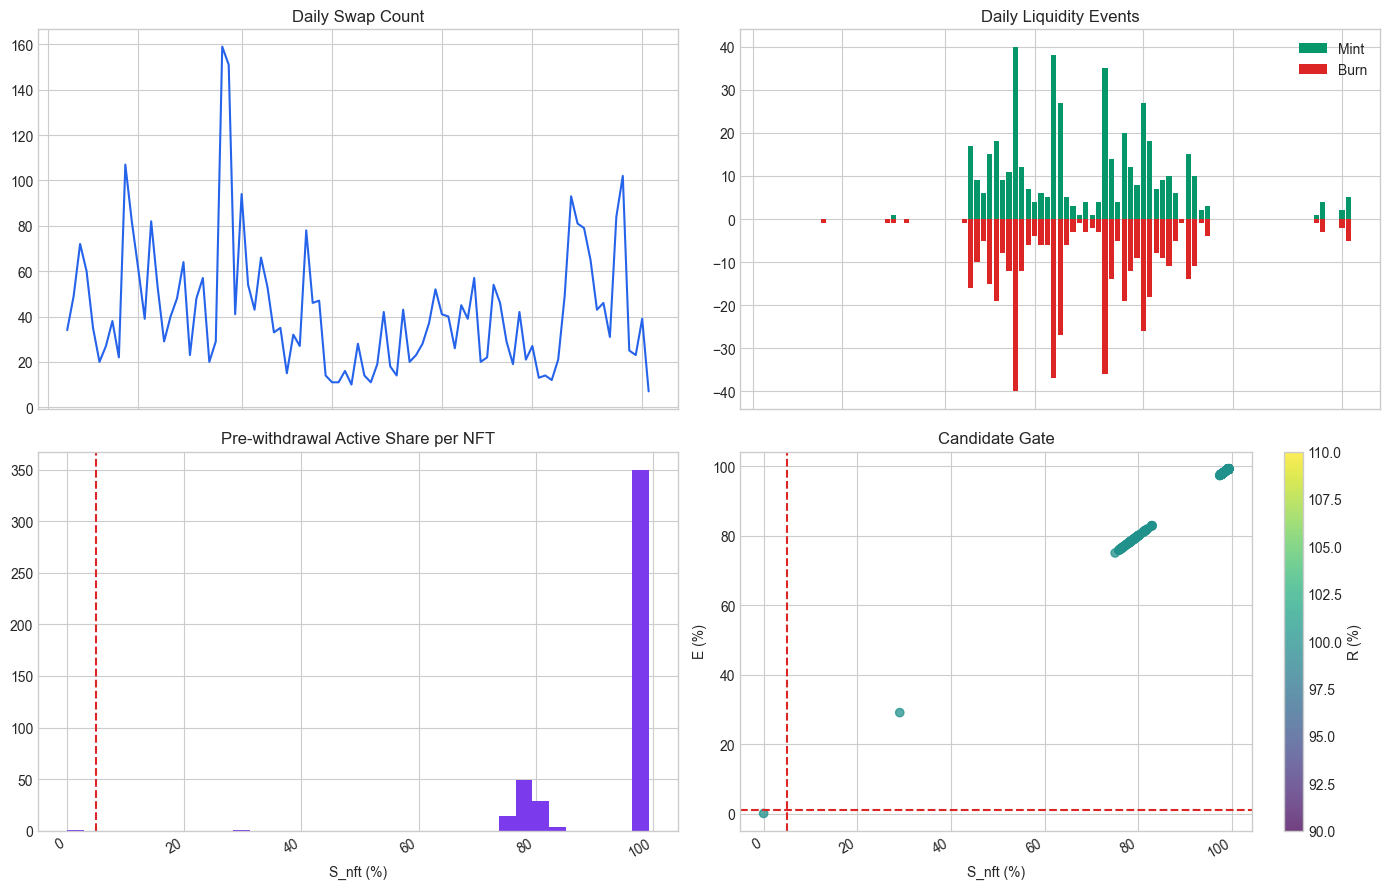

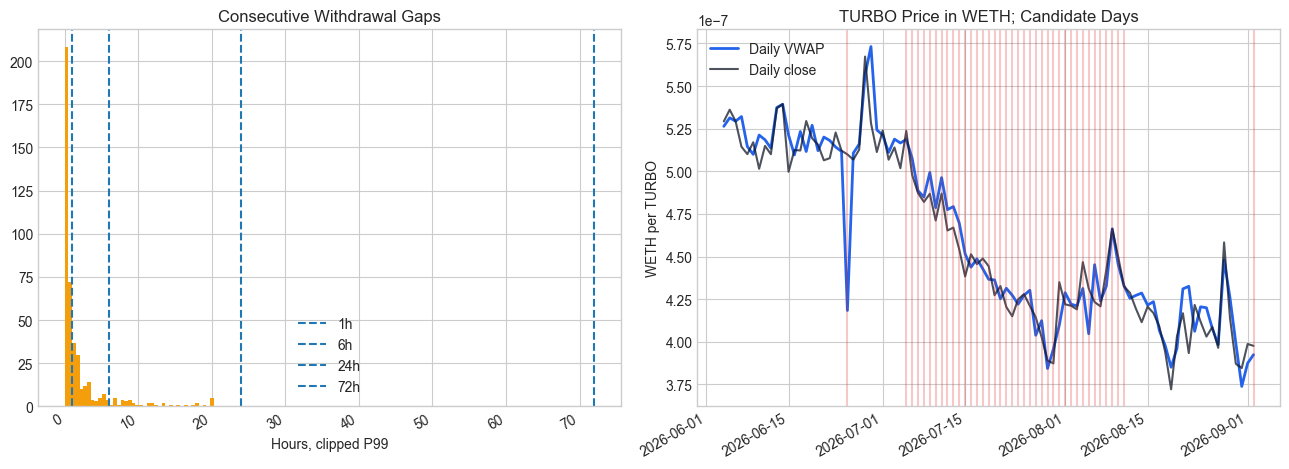

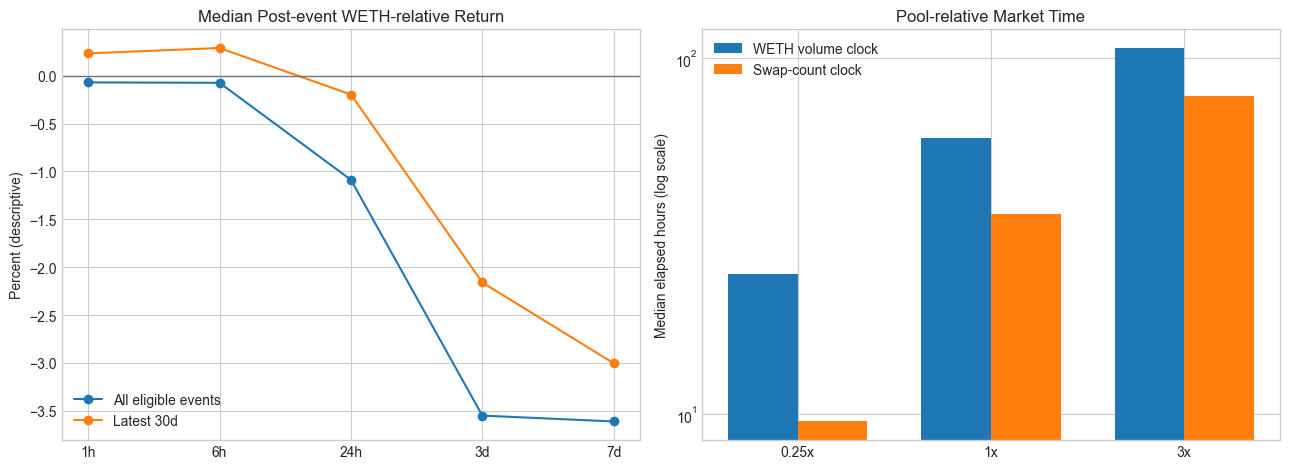

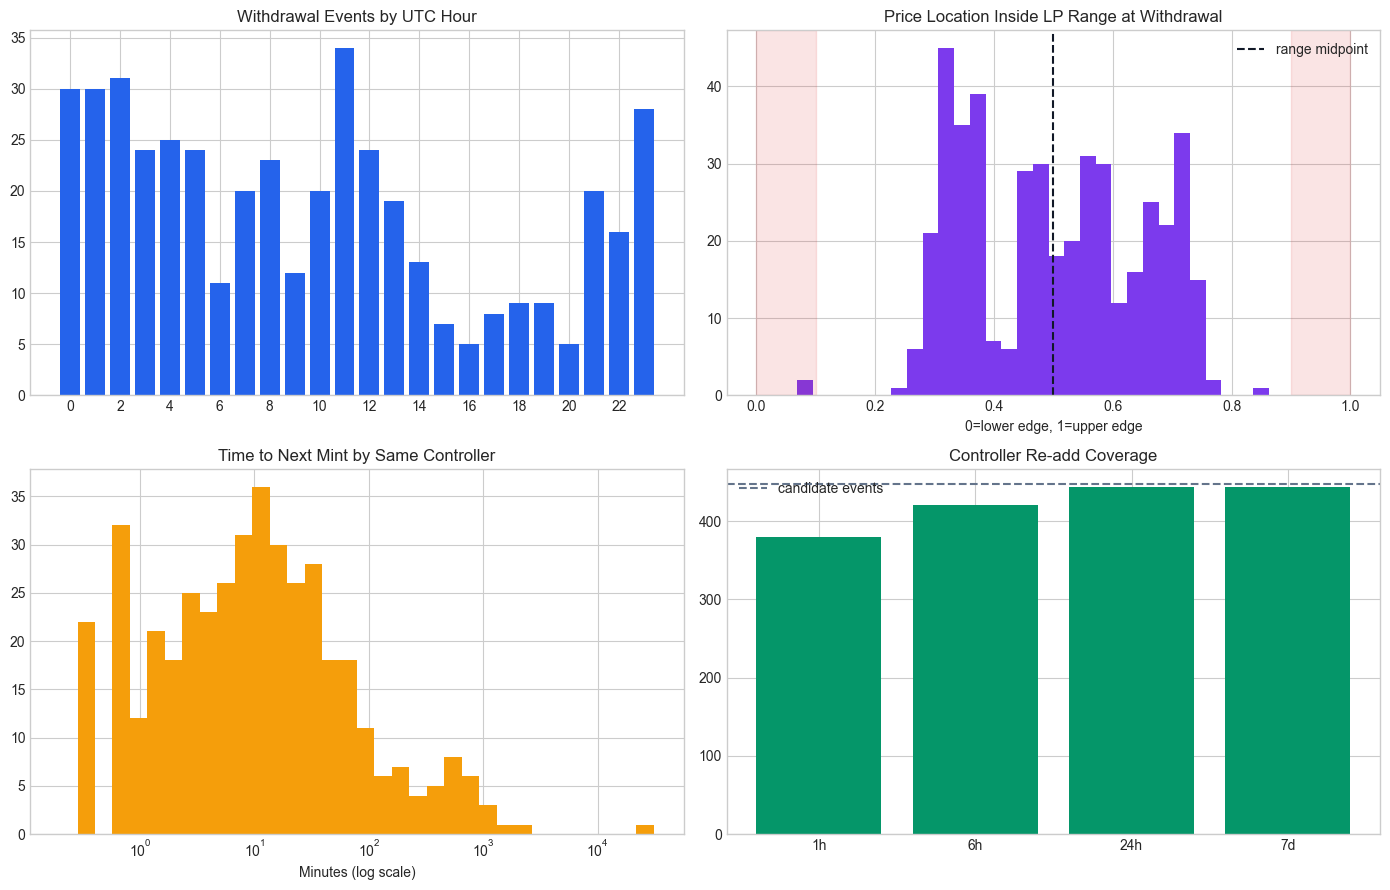

### 描述性结论
- 窗口：`2026-06-04T03:20:59+00:00` 至 `2026-09-02T03:20:59+00:00`。
- 3,879 次 Swap、455 次 Mint、460 次 Burn。
- 恢复 451 次撤资历史状态，其中 448 次撤资前处于有效区间。
- 主门槛候选 447 次，涉及 447 个 NFT、2 个观测所有者。
- 7 天内同一控制地址再次 Mint 446 次，其中新 NFT 446 次。
- 主导地址的再加仓中位等待时间约 8.0 分钟；在区间边缘 10% 内撤资的比例仅 0.4%。
- 双时间尺度结果覆盖 446 个具有完整前 30 日基准的候选事件；其中 62 个位于样本最后 30 日。
- **发现单 NFT 满足 S≥5% 且 E≥1%，通过保守事件门控。**

注意：候选事件高度重叠，不能把事件数量理解为同等数量的独立大户或独立风险信号。本 Notebook 不展开最终受益人归属，也不包含决策树。

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0,0].plot(daily.date_utc, daily.swap_count, color="#2563eb"); axes[0,0].set_title("Daily Swap Count")
axes[0,1].bar(daily.date_utc, daily.add_count, color="#059669", label="Mint"); axes[0,1].bar(daily.date_utc, -daily.remove_count, color="#dc2626", label="Burn"); axes[0,1].set_title("Daily Liquidity Events"); axes[0,1].legend()
active = withdrawal_states[withdrawal_states.position_active_before]
if len(active): axes[1,0].hist(active.S_nft_pct.clip(upper=active.S_nft_pct.quantile(.99)), bins=35, color="#7c3aed")
axes[1,0].axvline(5, color="#dc2626", linestyle="--"); axes[1,0].set_title("Pre-withdrawal Active Share per NFT"); axes[1,0].set_xlabel("S_nft (%)")
if len(active):
    points = axes[1,1].scatter(active.S_nft_pct, active.E_pct, c=active.R_pct, cmap="viridis", alpha=.75); fig.colorbar(points, ax=axes[1,1], label="R (%)")
axes[1,1].axvline(5, color="#dc2626", linestyle="--"); axes[1,1].axhline(1, color="#dc2626", linestyle="--"); axes[1,1].set_title("Candidate Gate"); axes[1,1].set_xlabel("S_nft (%)"); axes[1,1].set_ylabel("E (%)")
fig.autofmt_xdate(); fig.tight_layout(); overview = FIGURE_DIR / "turbo_lp_whale_feasibility_overview.png"; fig.savefig(overview, dpi=180, bbox_inches="tight"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
if len(gaps): axes[0].hist((gaps/3600).clip(upper=max(1, (gaps/3600).quantile(.99))), bins=40, color="#f59e0b")
for threshold in (1,6,24,72): axes[0].axvline(threshold, linestyle="--", label=f"{threshold}h")
axes[0].set_title("Consecutive Withdrawal Gaps"); axes[0].set_xlabel("Hours, clipped P99"); axes[0].legend()
axes[1].plot(daily.date_utc, daily.price_vwap_weth, color="#2563eb", linewidth=2, label="Daily VWAP")
axes[1].plot(daily.date_utc, daily.price_close_weth, color="#111827", alpha=.75, label="Daily close")
if len(candidate_events):
    for day in sorted(set(pd.to_datetime(candidate_events.datetime_utc, utc=True).dt.floor("D"))): axes[1].axvline(day, color="#dc2626", alpha=.25)
axes[1].set_title("TURBO Price in WETH; Candidate Days"); axes[1].set_ylabel("WETH per TURBO"); axes[1].legend()
fig.autofmt_xdate(); fig.tight_layout(); timing = FIGURE_DIR / "turbo_lp_withdrawal_timing.png"; fig.savefig(timing, dpi=180, bbox_inches="tight"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
horizon_labels = ["1h", "6h", "24h", "3d", "7d"]
return_columns = [f"real_{label}_return_pct" for label in horizon_labels]
all_medians = [market_event_metrics[column].median() for column in return_columns]
recent = market_event_metrics[market_event_metrics.is_latest_30d]
recent_medians = [recent[column].median() for column in return_columns]
x = np.arange(len(horizon_labels)); axes[0].plot(x, all_medians, marker="o", label="All eligible events"); axes[0].plot(x, recent_medians, marker="o", label="Latest 30d")
axes[0].axhline(0, color="#64748b", linewidth=1); axes[0].set_xticks(x, horizon_labels); axes[0].set_title("Median Post-event WETH-relative Return"); axes[0].set_ylabel("Percent (descriptive)"); axes[0].legend()
volume_elapsed = [market_event_metrics[f"volume_{str(m).replace('.', '_')}x_elapsed_hours"].median() for m in market_multipliers]
count_elapsed = [market_event_metrics[f"count_{str(m).replace('.', '_')}x_elapsed_hours"].median() for m in market_multipliers]
labels = [f"{m:.2g}x" for m in market_multipliers]; width=.36; xx=np.arange(len(labels))
axes[1].bar(xx-width/2, volume_elapsed, width, label="WETH volume clock"); axes[1].bar(xx+width/2, count_elapsed, width, label="Swap-count clock")
axes[1].set_xticks(xx, labels); axes[1].set_yscale("log"); axes[1].set_ylabel("Median elapsed hours (log scale)"); axes[1].set_title("Pool-relative Market Time"); axes[1].legend()
fig.tight_layout(); dual = FIGURE_DIR / "turbo_lp_dual_time_outcomes.png"; fig.savefig(dual, dpi=180, bbox_inches="tight"); plt.show()

behavior = withdrawals_with_readd[withdrawals_with_readd.candidate_main].copy()
behavior["datetime_utc"] = pd.to_datetime(behavior.datetime_utc, utc=True); behavior["utc_hour"] = behavior.datetime_utc.dt.hour
behavior["range_position"] = (behavior.tick_current-behavior.tick_lower)/(behavior.tick_upper-behavior.tick_lower)
behavior_summary = pd.DataFrame([{"candidate_events": len(behavior), "dominant_owner_events": int((behavior.owner_before.str.lower()=="0xc216bfa5da000965e820845c32e6fd88db275743").sum()),
    "median_range_position": float(behavior.range_position.median()), "near_range_edge_share": float(((behavior.range_position<=.1)|(behavior.range_position>=.9)).mean()),
    "median_readd_minutes": float(behavior.controller_readd_gap_seconds.dropna().median()/60), "same_range_readd_share": float((behavior.same_tick_range.eq(True)&behavior.controller_readd_within_7d.eq(True)).mean()),
    "median_readd_liquidity_ratio": float(behavior.readd_vs_removed_ratio.dropna().median())}])
behavior_summary.to_csv(DATA_DIR / "behavior_pattern_summary.csv", index=False)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
hour_counts = behavior.utc_hour.value_counts().reindex(range(24), fill_value=0); axes[0,0].bar(hour_counts.index, hour_counts.values, color="#2563eb"); axes[0,0].set_xticks(range(0,24,2)); axes[0,0].set_title("Withdrawal Events by UTC Hour")
axes[0,1].hist(behavior.range_position, bins=30, color="#7c3aed"); axes[0,1].axvline(.5, color="#111827", linestyle="--", label="range midpoint"); axes[0,1].axvspan(0,.1,color="#dc2626",alpha=.12); axes[0,1].axvspan(.9,1,color="#dc2626",alpha=.12); axes[0,1].set_title("Price Location Inside LP Range at Withdrawal"); axes[0,1].set_xlabel("0=lower edge, 1=upper edge"); axes[0,1].legend()
valid_gaps = behavior.controller_readd_gap_seconds.dropna()/60; axes[1,0].hist(valid_gaps, bins=np.logspace(np.log10(max(valid_gaps.min(),.01)),np.log10(valid_gaps.max()),35),color="#f59e0b"); axes[1,0].set_xscale("log"); axes[1,0].set_title("Time to Next Mint by Same Controller"); axes[1,0].set_xlabel("Minutes (log scale)")
window_counts = [int((behavior.controller_readd_gap_seconds<=seconds).sum()) for seconds in (3600,6*3600,24*3600,7*86400)]; axes[1,1].bar(["1h","6h","24h","7d"],window_counts,color="#059669"); axes[1,1].axhline(len(behavior),color="#64748b",linestyle="--",label="candidate events"); axes[1,1].set_title("Controller Re-add Coverage"); axes[1,1].legend()
fig.tight_layout(); patterns = FIGURE_DIR / "turbo_lp_behavior_patterns.png"; fig.savefig(patterns,dpi=180,bbox_inches="tight"); plt.show()

summary = {**window, "swap_count": int(len(swaps)), "mint_count": int(len(mints)), "burn_count": int(len(burns)),
    "matched_burn_count": int((position_events.pool_event.eq("Burn") & position_events.token_id.notna()).sum()),
    "historical_state_count": int(len(withdrawal_states)), "active_before_count": int(withdrawal_states.position_active_before.sum()),
    "main_candidate_event_count": int(withdrawal_states.candidate_main.sum()), "main_candidate_unique_nfts": int(candidate_events.token_id.nunique()),
    "main_candidate_unique_observed_owners": int(candidate_events.owner_before.nunique()), "control_candidate_event_count": int(withdrawal_states.candidate_control.sum()),
    "controller_readd_within_7d_count": int(readds.controller_readd_within_7d.eq(True).sum()), "new_nft_readd_count": int((readds.controller_readd_within_7d.eq(True) & readds.new_nft.eq(True)).sum()),
    "market_outcome_events_with_30d_baseline": int(len(market_event_metrics)), "latest_30d_market_outcome_events": int(market_event_metrics.is_latest_30d.sum()), "single_nft_gate_passed": bool(len(candidate_events)),
    "identity_scope": "historical ownerOf; custody contracts not unwrapped", "share_scope": "single NFT exact share; controller aggregate lower bound"}
(DATA_DIR / "feasibility_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
verdict = "发现单 NFT 满足 S≥5% 且 E≥1%，通过保守事件门控。" if len(candidate_events) else "未发现单 NFT 同时满足主门槛；多 NFT 控制者聚合仍待核验。"
display(Markdown(f"""### 描述性结论
- 窗口：`{window['from_utc']}` 至 `{window['to_utc']}`。
- {len(swaps):,} 次 Swap、{len(mints):,} 次 Mint、{len(burns):,} 次 Burn。
- 恢复 {len(withdrawal_states):,} 次撤资历史状态，其中 {int(withdrawal_states.position_active_before.sum()):,} 次撤资前处于有效区间。
- 主门槛候选 {len(candidate_events):,} 次，涉及 {candidate_events.token_id.nunique()} 个 NFT、{candidate_events.owner_before.nunique()} 个观测所有者。
- 7 天内同一控制地址再次 Mint {int(readds.controller_readd_within_7d.eq(True).sum()):,} 次，其中新 NFT {int((readds.controller_readd_within_7d.eq(True) & readds.new_nft.eq(True)).sum()):,} 次。
- 主导地址的再加仓中位等待时间约 {behavior.controller_readd_gap_seconds.dropna().median()/60:.1f} 分钟；在区间边缘 10% 内撤资的比例仅 {100*((behavior.range_position<=.1)|(behavior.range_position>=.9)).mean():.1f}%。
- 双时间尺度结果覆盖 {len(market_event_metrics):,} 个具有完整前 30 日基准的候选事件；其中 {int(market_event_metrics.is_latest_30d.sum()):,} 个位于样本最后 30 日。
- **{verdict}**

注意：候选事件高度重叠，不能把事件数量理解为同等数量的独立大户或独立风险信号。本 Notebook 不展开最终受益人归属，也不包含决策树。"""))